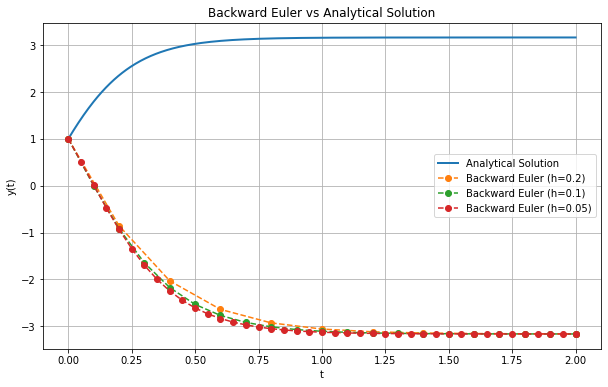

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2*y

def backward_euler_step(f, y, t, h, tol=1e-8, max_iter=50):
    y_next = y  # initial guess
    
    for _ in range(max_iter):
        g = y_next - y - h * f(t + h, y_next)
        g_prime = 1 - h * fprime(y_next)
        
        if abs(g_prime) < 1e-12:
            break
        
        y_new = y_next - g / g_prime
        
        if abs(y_new - y_next) < tol:
            return y_new
        
        y_next = y_new
    
    return y_next

def backward_euler(f, y0, t0, tf, h):
    t_vals = [t0]
    y_vals = [y0]
    
    t = t0
    y = y0
    
    while t < tf:
        if t + h > tf:
            h = tf - t
        
        y = backward_euler_step(f, y, t, h)
        t += h
        
        t_vals.append(t)
        y_vals.append(y)
    
    return np.array(t_vals), np.array(y_vals)

def analytical_solution(t, y0):
    sqrt10 = np.sqrt(10)
    
    # Compute constant C
    C = np.arctanh(y0 / sqrt10) / sqrt10
    
    return sqrt10 * np.tanh(sqrt10 * (t + C))

y0 = 1.0
t0 = 0.0
tf = 2.0

h_values = [0.2, 0.1, 0.05]

t_exact = np.linspace(t0, tf, 500)
y_exact = analytical_solution(t_exact, y0)

plt.figure(figsize=(10, 6))

plt.plot(t_exact, y_exact, linewidth=2, label="Analytical Solution")

for h in h_values:
    t_num, y_num = backward_euler(f, y0, t0, tf, h)
    plt.plot(t_num, y_num, marker='o', linestyle='--', label=f"Backward Euler (h={h})")

plt.title("Backward Euler vs Analytical Solution")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)

plt.show()